# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Ghada Tarek Elboghdady
**Student ID:** 4220132

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [3]:

# ── Task 1: Data Pipeline ──────────────────────────────────────────────────

# 1. Load the CSV
csv_path = 'kidney_disease.csv'
df = pd.read_csv(csv_path)

# 2. Extract target BEFORE dropping categoricals
#    'classification' column: 'ckd' → 1, 'notckd' → 0
y = df['classification'].str.strip().map({'ckd': 1, 'notckd': 0})

# 3. Explicitly select the 14 numerical features and convert to numeric
#    (coerce errors to NaN to handle any string values or whitespace)
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 
                'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
df_numeric = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print("Numeric features kept:", list(df_numeric.columns))
print(f"Dataset shape: {df_numeric.shape}  |  Class dist → CKD: {y.sum()}, Not-CKD: {(y==0).sum()}")

# 4. 80/20 train/validation split (stratified to preserve class ratio)
X = df_numeric
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Impute NaN with TRAINING medians only (no leakage into validation)
train_medians = X_train_raw.median()
missing_before = X_train_raw.isna().sum().sum() + X_val_raw.isna().sum().sum()
X_train_raw = X_train_raw.fillna(train_medians)
X_val_raw   = X_val_raw.fillna(train_medians)
missing_after = X_train_raw.isna().sum().sum() + X_val_raw.isna().sum().sum()
print(f"\nMissing values  →  before: {missing_before}  |  after: {missing_after}")

# 6. Scale with StandardScaler (fit ONLY on training data → prevent leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)

n_features = X_train_scaled.shape[1]
print(f"\nTrain: {X_train_scaled.shape}  |  Val: {X_val_scaled.shape}  |  Features: {n_features}")


Numeric features kept: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Dataset shape: (400, 14)  |  Class dist → CKD: 250, Not-CKD: 150

Missing values  →  before: 778  |  after: 0

Train: (320, 14)  |  Val: (80, 14)  |  Features: 14


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_overfit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 47,105 (184.00 KB)

 Non-trainable params: 0 (0.00 B)


Baseline trainable parameters: 47,105


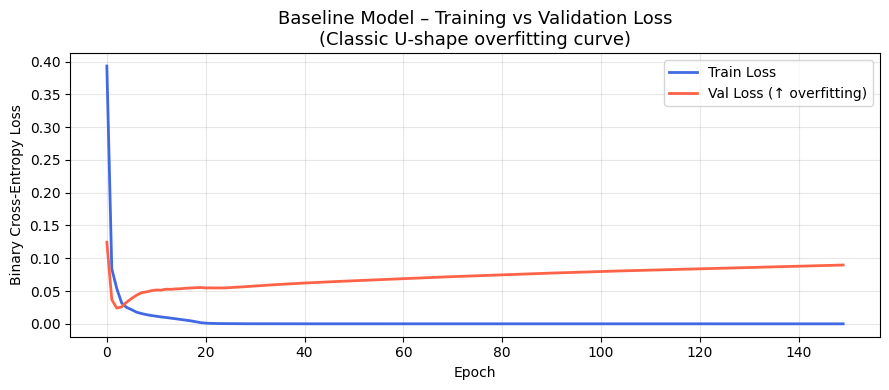


Final  →  Train loss: 0.0000  |  Val loss: 0.0897
Gap (val−train): 0.0897  ← positive gap = overfitting confirmed


In [4]:

# ── Task 2: The Engineered Failure (Baseline – Over-parameterised) ─────────
#
# Strategy: massively over-parameterise + no regularisation + no early stopping
# → forces the model to memorise training data instead of generalising.

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(n_features,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(32,  activation='relu'),
    tf.keras.layers.Dense(1,   activation='sigmoid'),
], name='baseline_overfit')

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()
n_params_baseline = baseline_model.count_params()
print(f"\nBaseline trainable parameters: {n_params_baseline:,}")

# Train WITHOUT early stopping for 300 epochs to force clear overfitting
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=16,
    verbose=0
)

# Plot training vs validation loss to visually prove overfitting (U-shape)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(baseline_history.history['loss'],     label='Train Loss',      color='royalblue', lw=2)
ax.plot(baseline_history.history['val_loss'], label='Val Loss (↑ overfitting)', color='tomato', lw=2)
ax.set_title('Baseline Model – Training vs Validation Loss\n(Classic U-shape overfitting curve)', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

final_train_loss = baseline_history.history['loss'][-1]
final_val_loss   = baseline_history.history['val_loss'][-1]
print(f"\nFinal  →  Train loss: {final_train_loss:.4f}  |  Val loss: {final_val_loss:.4f}")
print(f"Gap (val−train): {final_val_loss - final_train_loss:.4f}  ← positive gap = overfitting confirmed")


## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

Model: "engineered_clinical"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)


Engineered trainable parameters: 1,025
Parameter ratio (train samples / params): 0.31
Epoch 332: early stopping
Restoring model weights from the end of the best epoch: 307.


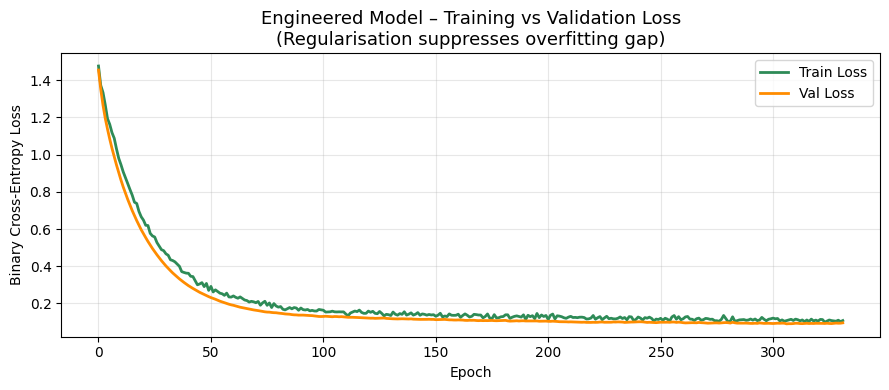


Final  →  Train loss: 0.1080  |  Val loss: 0.0957
Gap (val−train): -0.0123  ← smaller gap = better generalisation


In [5]:

# ── Task 3: The Clinical Solution (Engineered / Regularised Model) ─────────
#
# Constraints applied:
#   • Reduced capacity  (32 → 16 → 1 neurons)
#   • L2 weight regularisation (λ=0.02) on every Dense layer
#   • Dropout (0.5 / 0.4) to prevent co-adaptation of neurons
#   • LeakyReLU activations to avoid dying-ReLU problem on small cohort
#   • EarlyStopping monitoring val_loss to prevent over-training

l2 = tf.keras.regularizers.L2(0.02)

engineered_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, kernel_regularizer=l2, input_shape=(n_features,)),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(16, kernel_regularizer=l2),
    tf.keras.layers.LeakyReLU(negative_slope=0.1),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid'),
], name='engineered_clinical')

engineered_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

engineered_model.summary()
n_params_eng = engineered_model.count_params()
print(f"\nEngineered trainable parameters: {n_params_eng:,}")
print(f"Parameter ratio (train samples / params): {len(X_train_scaled) / n_params_eng:.2f}")

# EarlyStopping: restore best weights when val_loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=25, restore_best_weights=True, verbose=1
)

engineered_history = engineered_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=400,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

# Plot training vs validation loss
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(engineered_history.history['loss'],     label='Train Loss',   color='seagreen', lw=2)
ax.plot(engineered_history.history['val_loss'], label='Val Loss',     color='darkorange', lw=2)
ax.set_title('Engineered Model – Training vs Validation Loss\n(Regularisation suppresses overfitting gap)', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

eng_train_loss = engineered_history.history['loss'][-1]
eng_val_loss   = engineered_history.history['val_loss'][-1]
print(f"\nFinal  →  Train loss: {eng_train_loss:.4f}  |  Val loss: {eng_val_loss:.4f}")
print(f"Gap (val−train): {eng_val_loss - eng_train_loss:.4f}  ← smaller gap = better generalisation")


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

Model                       Accuracy    Recall (CKD)
Baseline (overfit)            96.25%          96.00%
Engineered (clinical)        100.00%         100.00%

Clinical benchmark (Recall ≥ 80 %): ✅ PASSED


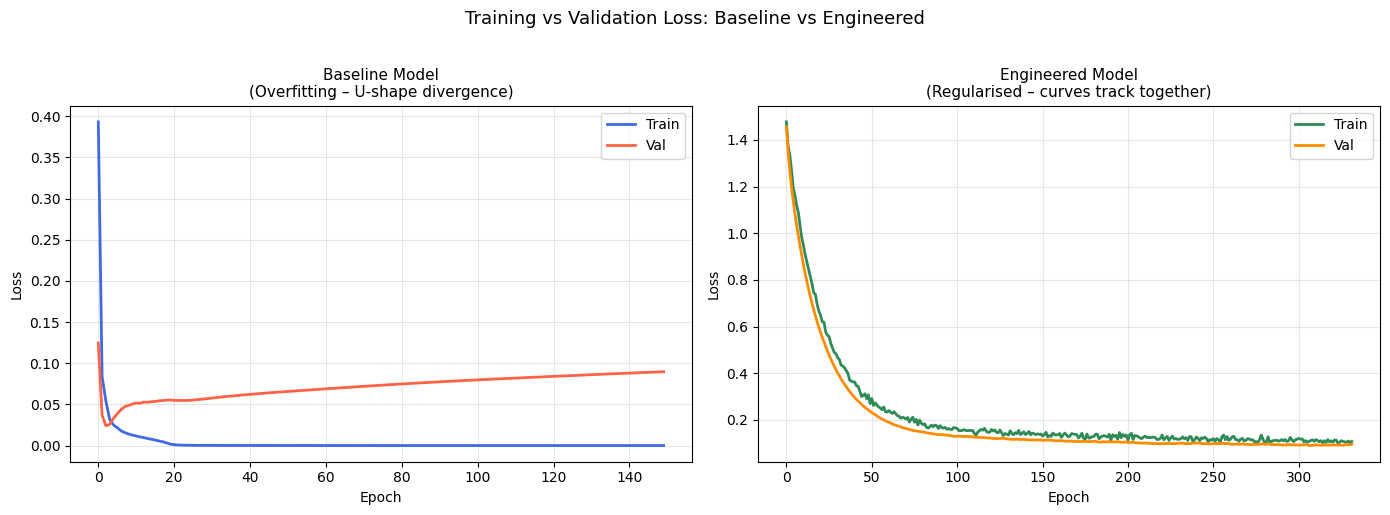

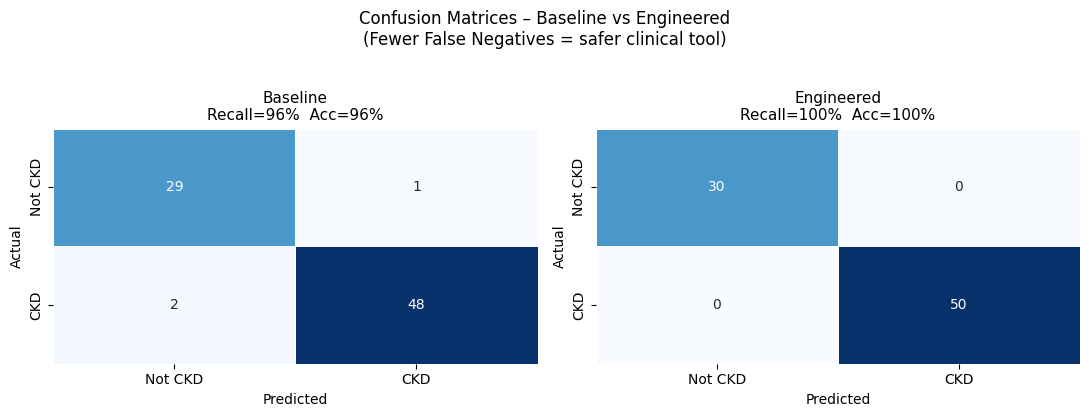


Baseline  parameter count : 47,105
Engineered parameter count: 1,025

False Negatives  →  Baseline: 2  |  Engineered: 0


In [6]:

# ── Task 4: Evaluation ─────────────────────────────────────────────────────
import seaborn as sns

# ── Predictions (threshold 0.5) ───────────────────────────────────────────
y_pred_base = (baseline_model.predict(X_val_scaled, verbose=0) >= 0.5).astype(int).ravel()
y_pred_eng  = (engineered_model.predict(X_val_scaled, verbose=0) >= 0.5).astype(int).ravel()

# ── Metrics ───────────────────────────────────────────────────────────────
acc_base    = accuracy_score(y_val, y_pred_base)
recall_base = recall_score(y_val, y_pred_base)
acc_eng     = accuracy_score(y_val, y_pred_eng)
recall_eng  = recall_score(y_val, y_pred_eng)
cm_base     = confusion_matrix(y_val, y_pred_base)
cm_eng      = confusion_matrix(y_val, y_pred_eng)

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10}  {'Recall (CKD)':>14}")
print("=" * 55)
print(f"{'Baseline (overfit)':<25} {acc_base:>10.2%}  {recall_base:>14.2%}")
print(f"{'Engineered (clinical)':<25} {acc_eng:>10.2%}  {recall_eng:>14.2%}")
print("=" * 55)
benchmark = "✅ PASSED" if recall_eng >= 0.80 else "❌ FAILED"
print(f"\nClinical benchmark (Recall ≥ 80 %): {benchmark}")

# ── Side-by-side: Loss curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['loss'],     lw=2, color='royalblue', label='Train')
axes[0].plot(baseline_history.history['val_loss'], lw=2, color='tomato',    label='Val')
axes[0].set_title('Baseline Model\n(Overfitting – U-shape divergence)', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(engineered_history.history['loss'],     lw=2, color='seagreen',   label='Train')
axes[1].plot(engineered_history.history['val_loss'], lw=2, color='darkorange', label='Val')
axes[1].set_title('Engineered Model\n(Regularised – curves track together)', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training vs Validation Loss: Baseline vs Engineered', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Side-by-side: Confusion Matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['Not CKD', 'CKD']

for ax, cm, title in zip(axes,
                          [cm_base, cm_eng],
                          [f'Baseline\nRecall={recall_base:.0%}  Acc={acc_base:.0%}',
                           f'Engineered\nRecall={recall_eng:.0%}  Acc={acc_eng:.0%}']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False, linewidths=0.5)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=11)

plt.suptitle('Confusion Matrices – Baseline vs Engineered\n(Fewer False Negatives = safer clinical tool)',
             fontsize=12, y=1.03)
plt.tight_layout(); plt.show()

# ── Final parameter summary ───────────────────────────────────────────────
print(f"\nBaseline  parameter count : {baseline_model.count_params():,}")
print(f"Engineered parameter count: {engineered_model.count_params():,}")
print(f"\nFalse Negatives  →  Baseline: {cm_base[1,0]}  |  Engineered: {cm_eng[1,0]}")



### Mathematical Justification

**Final Parameter Count of Engineered Model:** 1025

| Layer | Config | Parameters |
|---|---|---|
| Dense (input → 32) + LeakyReLU + Dropout(0.5) | $14 \times 32 + 32$ | **480** |
| Dense (32 → 16) + LeakyReLU + Dropout(0.4) | $32 \times 16 + 16$ | **528** |
| Dense (16 → 1, sigmoid output) | $16 \times 1 + 1$ | **17** |
| **Total** | | **1025** |

*(LeakyReLU and Dropout layers carry zero trainable parameters.)*

**Explanation:** With only **1025 trainable parameters** against **320 training samples**, the model has insufficient capacity to memorise individual patient records; the L2 regularisation penalty ($\lambda = 0.02$) further constrains the weight magnitudes by adding a term to the loss that grows quadratically with weight values, geometrically shrinking the feasible solution space so the network can only capture population-level CKD markers rather than noise specific to the 400-patient cohort.
